In [1]:
from google.colab import drive
drive.mount('/content/drive')

dir_ = '/content/drive/MyDrive/Cohand/Minh học data/Kỳ 3/NLP/'
raw_data = dir_ + 'data/raw/'
processed_data = dir_ + 'data/processed/'
requirment_file = dir_ + 'requirements.txt'
output = dir_ + 'output/'

Mounted at /content/drive



=== BẢNG SO SÁNH F1-SCORE TỔNG THỂ ===


Model,BiLSTM,Logistic Regression + TF-IDF,PhoBERT,XLM_RoBERTa
Label,,,,
macro avg,0.333999,0.588549,0.430588,0.519696
micro avg,0.776249,0.807194,0.872649,0.891484
weighted avg,0.714480,0.835867,0.826546,0.863097


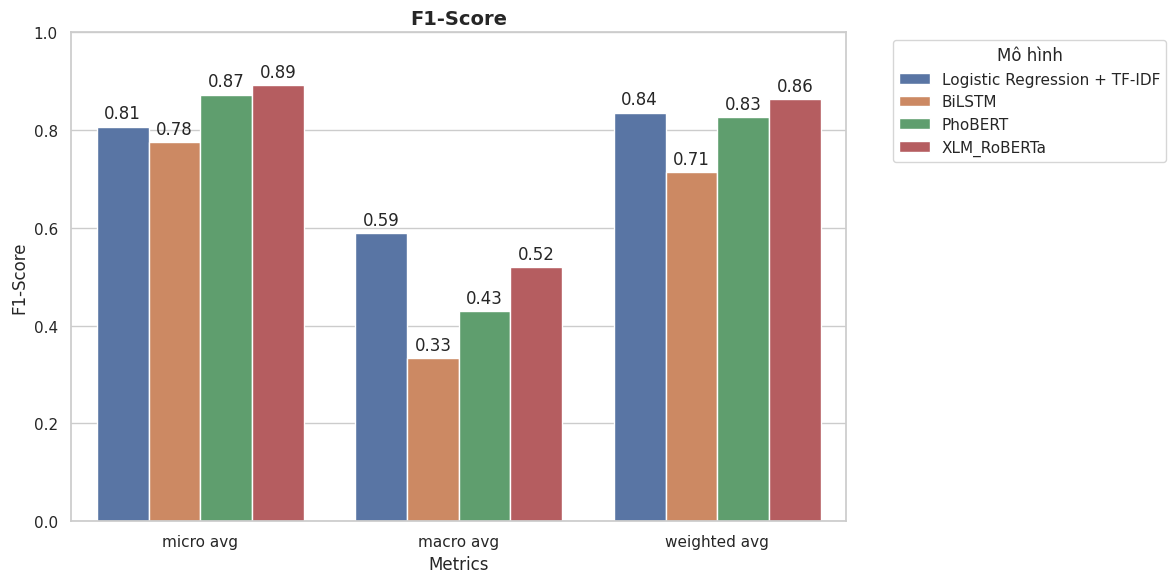

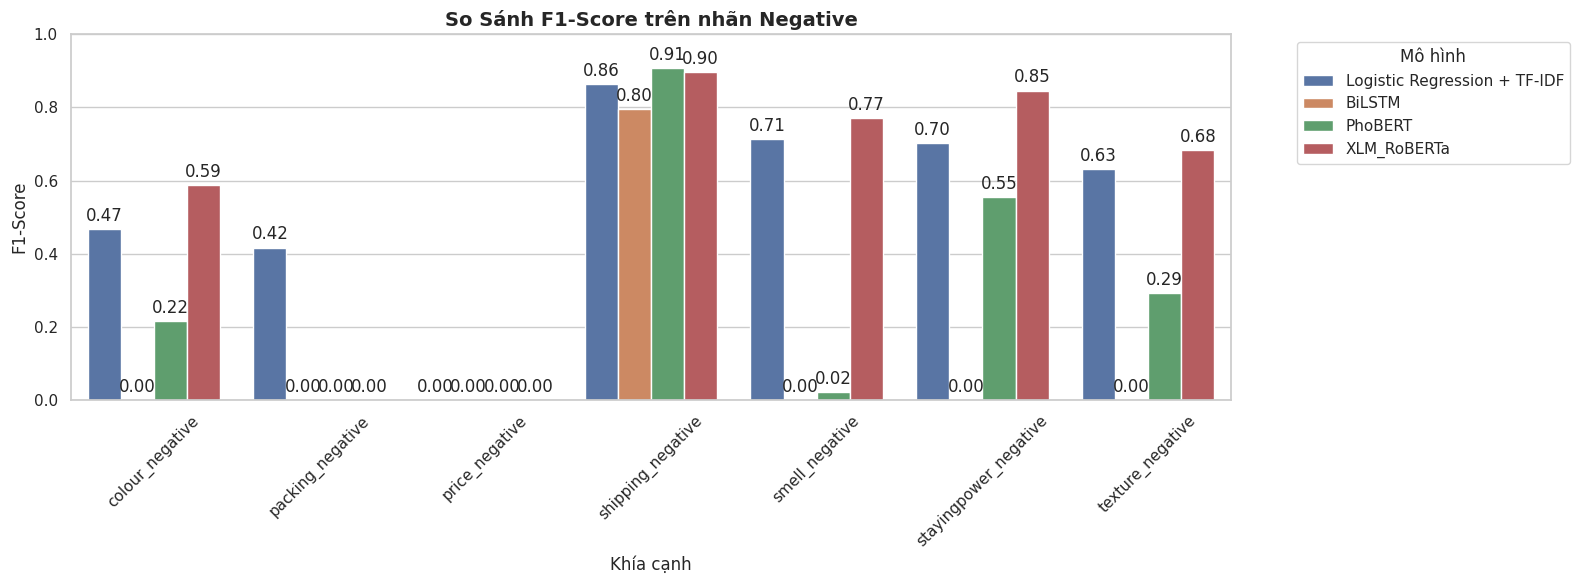

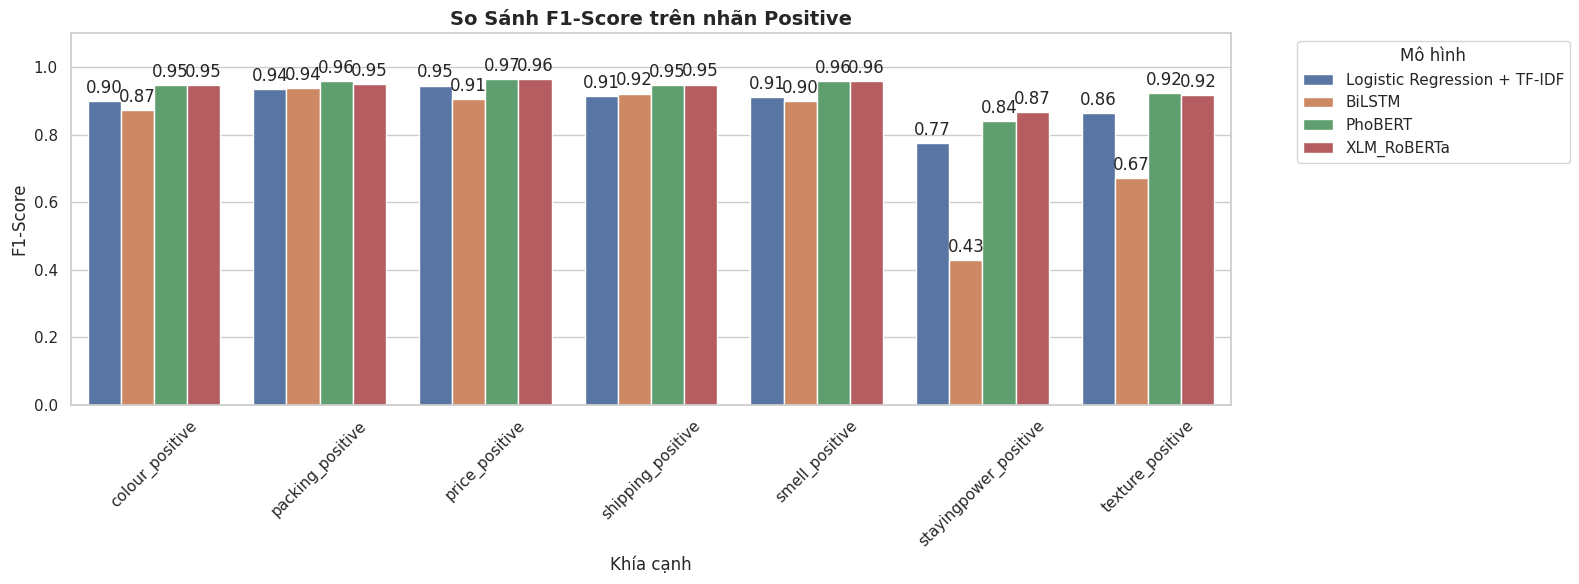

In [2]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns

folder_path = output

# Lấy danh sách tất cả các file có đuôi .csv trong folder
all_files = glob.glob(os.path.join(folder_path, "*.csv"))

df_list = []
for file in all_files:
    df = pd.read_csv(file)
    df_list.append(df)

# Gộp thành 1 DataFrame duy nhất
df_all = pd.concat(df_list, axis=0, ignore_index=True)

df_all.loc[df_all['Model'] == 'bilstm', 'Model'] = 'BiLSTM'
df_all.loc[df_all['Model'] == 'logistic_regression_tf_idf', 'Model'] = 'Logistic Regression + TF-IDF'


# ==========================================
# 2. Pivot table
# ==========================================
avg_metrics = ['macro avg', 'micro avg', 'weighted avg']
df_avg = df_all[df_all['Label'].isin(avg_metrics)]

f1_pivot = df_avg.pivot(index='Label', columns='Model', values='f1-score')

print("\n=== BẢNG SO SÁNH F1-SCORE TỔNG THỂ ===")
display(f1_pivot)


# ==========================================
# 3. Viz
# ==========================================
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))
ax1 = sns.barplot(data=df_avg, x='Label', y='f1-score', hue='Model')

for container in ax1.containers:
    ax1.bar_label(container, fmt='%.2f', padding=3, fontsize=12)

plt.title('F1-Score', fontsize=14, fontweight='bold')
plt.xlabel('Metrics', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.ylim(0, 1.0)
plt.legend(title='Mô hình', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

# ==========================================
# 4. Negative
# ==========================================

df_negative = df_all[df_all['Label'].str.contains('negative')]

plt.figure(figsize=(16, 6))
ax2 = sns.barplot(data=df_negative, x='Label', y='f1-score', hue='Model')

for container in ax2.containers:
    ax2.bar_label(container, fmt='%.2f', padding=3, fontsize=12)

plt.title('So Sánh F1-Score trên nhãn Negative', fontsize=14, fontweight='bold')
plt.xlabel('Khía cạnh', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, 1.0)
plt.legend(title='Mô hình', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.savefig('Chart_Negative_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 4. Positive
# ==========================================
df_negative = df_all[df_all['Label'].str.contains('positive')]

plt.figure(figsize=(16, 6))
ax3 = sns.barplot(data=df_negative, x='Label', y='f1-score', hue='Model')

for container in ax3.containers:
    ax3.bar_label(container, fmt='%.2f', padding=3, fontsize=12)

plt.title('So Sánh F1-Score trên nhãn Positive', fontsize=14, fontweight='bold')
plt.xlabel('Khía cạnh', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, 1.1)
plt.legend(title='Mô hình', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()